# Comparing ERA5 sources - CDS vs NCAR

`atlite` offers two sources for the ERA5 dataset - CDS and NCAR. ERA5 is natively hosted on the Copernicus Data Store, which offers powerful retrieval functionality. However, it can only serve 400 simultaneous requests, so you often have to wait for hours in order to download data, which can be annoying and difficult to debug. CDS also requires setting up an account and managing API keys for authentication.

National Centre for Atmospheric research hosts a mirror of ERA5. They do not have a queue, and do not require authentication. However, they offer very limited server-side processing, which means you need to download a bit more data, and do more processing on device. Some of the CDS server-side processing is difficult to mimic locally, so there may be 'meteorologically insignificant' numerical differences between the two datasets if you decide to use non-default retrieval parameters.

This table summarises the differences between the two datasets:

|                      | CDS                  | NCAR          |
|----------------------|----------------------|---------------|
| atlite API           | same                 | same          |
| authentication/setup | API + accept license | none          |
| download queue       | 5min-8hrs            | none          |
| cutout size          | 1x                   | 1x            |
| download size        | 1x                   | ~1.5x         |
| data storage grid    | parameter-dependent  | 0.25deg. grid |

> **So which source should I use?** For very large cutouts (e.g. continents larger than Europe), and for workflows that already used CDS, use CDS. For everything else, NCAR is more convenient.

In this example we will demonstrate how to use the NCAR mirror of the ERA5 dataset within `atlite` and demonstrate the minor numerical differences between them. For a more detailed explanation on how to build cutouts, follow [this notebook](https://atlite.readthedocs.io/en/master/examples/create_cutout.html).

We start with the setup

In [1]:
import logging
from pathlib import Path

import numpy as np
import xarray as xr

import atlite

logging.basicConfig(level=logging.INFO)

/home/marcin/phd/code/atlite/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's download cutouts with both datasets:

In [2]:
TIME = "2013-01-01"
BOUNDS = (-4, 56, 1.5, 62)
CACHE = Path(".cache")
CACHE.mkdir(exist_ok=True)

cutout_CDS = atlite.Cutout(
    path=CACHE / "era5-cds-native.nc",
    module="era5",
    bounds=BOUNDS,
    time=TIME,
)
cutout_CDS.prepare()

/home/marcin/phd/code/atlite/atlite/cutout.py:156: UserWarning: Arguments module, bounds, time are ignored, since cutout is already built.
  warn(
INFO:atlite.data:Storing temporary files in /tmp/tmp09wafky3


<Cutout "era5-cds-native">
 x = -4.00 ⟷ 1.50, dx = 0.25
 y = 56.00 ⟷ 62.00, dy = 0.25
 time = 2013-01-01 ⟷ 2013-01-01, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

In [3]:
cutout_NCAR = atlite.Cutout(
    path=CACHE / "era5-ncar-native.nc",
    module="era5-ncar",
    bounds=BOUNDS,
    time=TIME,
)
cutout_NCAR.prepare(tmpdir=CACHE)

/home/marcin/phd/code/atlite/atlite/cutout.py:156: UserWarning: Arguments module, bounds, time are ignored, since cutout is already built.
  warn(
INFO:atlite.data:Storing temporary files in .cache


<Cutout "era5-ncar-native">
 x = -4.00 ⟷ 1.50, dx = 0.25
 y = 56.00 ⟷ 62.00, dy = 0.25
 time = 2013-01-01 ⟷ 2013-01-01, dt = h
 module = era5-ncar
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

As you can see, the API for both datasets is identical. The only change needed is replacing `module="era5"` with `module="era5-ncar"`. NCAR provides identical functionality. Now let's compare the data to prove it's identical.

In [4]:
common_vars = set(cutout_CDS.data.data_vars) & set(cutout_NCAR.data.data_vars)

print(
    "Both cutouts have the same features:",
    common_vars == set(cutout_CDS.data.data_vars),
)

try:
    xr.testing.assert_allclose(
        cutout_CDS.data[common_vars], cutout_NCAR.data[common_vars], atol=1e-4
    )
    print("Data in both features is identical")
except Exception:
    print("Data in both features is NOT identical")

Both cutouts have the same features: True
Data in both features is identical


This will always be true when pulling data at the default resolution of 0.25deg used by atlite (and also NCAR and CDS). 

The results will diverge slightly when you need to change the resolution. CDS uses it's [own interpolation library](https://confluence.ecmwf.int/display/UDOC/MARS+interpolation+with+MIR) to derive results at non-default resolutions. For NCAR data, we simply do linear interpolation from the 0.25deg. grid. Let's see where the differences are

INFO:atlite.cutout:Building new cutout .cache/era5-cds-interpolated.nc
INFO:atlite.data:Storing temporary files in /tmp/tmpfjkz_yf1
INFO:atlite.data:Calculating and writing with module era5:
INFO:atlite.datasets.era5:Requesting data for feature height...
INFO:atlite.datasets.era5:Requesting data for feature wind...
INFO:atlite.datasets.era5:Requesting data for feature influx...
INFO:atlite.datasets.era5:Requesting data for feature temperature...
INFO:atlite.datasets.era5:Requesting data for feature runoff...
INFO:atlite.datasets.era5:CDS: Downloading variables
	geopotential (['2013']-['01'])

INFO:multiurl.base:Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-2/2026-03-19/4e29df484c8b95f9bca07661b716c31f.grib
INFO:atlite.datasets.era5:CDS: Downloading variables                                                                                                                                          
	surface_net_solar_radiation (['2013']-['01'])
	surface_solar_ra

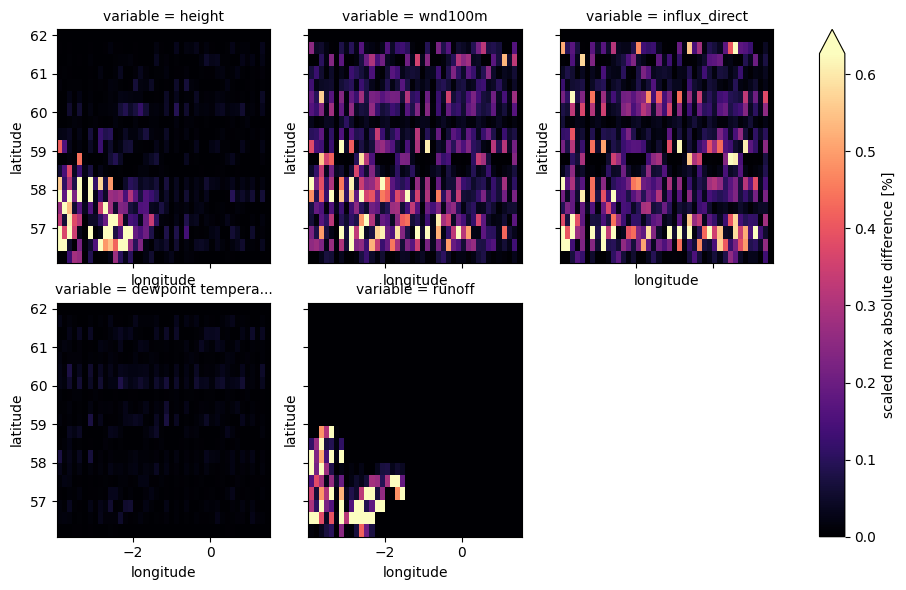

In [5]:
INTERPOLATED_DX = 0.132
INTERPOLATED_DY = 0.32
WORST_DIFF_VARS = [
    "height",
    "wnd100m",
    "influx_direct",
    "dewpoint temperature",
    "runoff",
]

cutout_interpolated_CDS = atlite.Cutout(
    path=CACHE / "era5-cds-interpolated.nc",
    module="era5",
    bounds=BOUNDS,
    time=TIME,
    dx=INTERPOLATED_DX,
    dy=INTERPOLATED_DY,
)
cutout_interpolated_CDS.prepare()

cutout_interpolated_NCAR = atlite.Cutout(
    path=CACHE / "era5-ncar-interpolated.nc",
    module="era5-ncar",
    bounds=BOUNDS,
    time=TIME,
    dx=INTERPOLATED_DX,
    dy=INTERPOLATED_DY,
)
cutout_interpolated_NCAR.prepare(tmpdir=CACHE)


def scaled_max_abs_diff(reference, candidate, eps=1e-12):
    diff = np.abs(candidate - reference)
    scale = float(np.maximum(np.abs(reference), np.abs(candidate)).max(skipna=True))
    if scale < eps:
        scale = 1.0
    reduce_dims = [dim for dim in diff.dims if dim not in {"x", "y"}]
    diff_map = diff.max(dim=reduce_dims, skipna=True) if reduce_dims else diff
    return 100 * diff_map.fillna(0) / scale


diff_maps = [
    scaled_max_abs_diff(
        cutout_interpolated_CDS.data[var],
        cutout_interpolated_NCAR.data[var],
    ).assign_coords(variable=var)
    for var in WORST_DIFF_VARS
]

relative_max_diff = xr.concat(diff_maps, dim="variable").rename(
    "scaled max absolute difference [%]"
)

grid = relative_max_diff.plot.pcolormesh(
    x="x",
    y="y",
    col="variable",
    col_wrap=3,
    cmap="magma",
    robust=True,
    cbar_kwargs={"label": "scaled max absolute difference [%]"},
)

for ax in grid.axs.flat:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")